### Imports

In [5]:

import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
data = pd.read_csv('PartII_dev.csv')



### PART 2 i) Selecting Hyperparameters and optimization

Number of features: 125
Number of samples: 158
Number of classes: Y
0    126
1     32
Name: count, dtype: int64
=== ANOVA Results ===
Feature  F-Statistic      P-Value  Significant
   X105    32.929074 4.833682e-08         True
   X103    29.630528 1.989584e-07         True
   X115    28.698951 2.982828e-07         True
   X113    28.466345 3.301451e-07         True
    X55    28.036949 3.983325e-07         True
   X101    27.298335 5.508606e-07         True
   X111    26.441247 8.040513e-07         True
    X65    26.388949 8.228789e-07         True
    X53    23.386948 3.150588e-06         True
     X5    23.110147 3.570824e-06         True
    X63    22.628268 4.443133e-06         True
    X76    21.952420 6.044712e-06         True
    X15    21.609610 7.070303e-06         True
    X51    21.561580 7.227494e-06         True
    X78    21.392165 7.810866e-06         True
    X61    20.916137 9.719656e-06         True
     X3    20.216924 1.341958e-05         True
    X13    19.405279

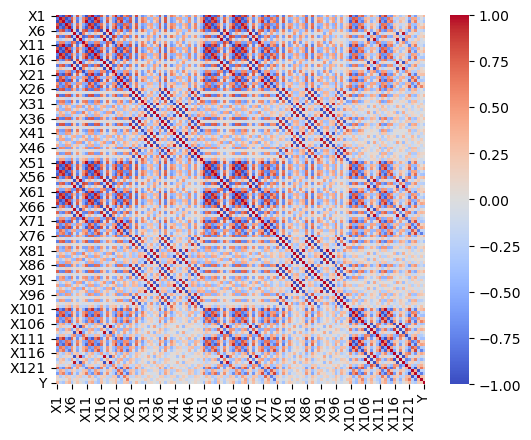

In [6]:
sns.heatmap(data.corr(), square=True, vmax=1, vmin=-1, center=0, cmap='coolwarm')

X = data.drop(columns=['Y'])
Y = data['Y']


print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {Y.value_counts()}")
# =====================================================================
# ANOVA F-TEST (appropriate for continuous features vs categorical target)
# =====================================================================
anova_results = []

for col in X.columns:
    groups = [X[col][Y == cls] for cls in Y.unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({'Feature': col, 'F-Statistic': f_stat, 'P-Value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('F-Statistic', ascending=False)
anova_df['Significant'] = anova_df['P-Value'] < 0.05

print("=== ANOVA Results ===")
print(anova_df.to_string(index=False))

# =====================================================================
# CHI-SQUARED TEST (only valid for non-negative integer/categorical features)
# Binning floats into quartiles to make it applicable
# =====================================================================
chi2_results = []

for col in X.columns:
    binned = pd.qcut(X[col], q=4, labels=False, duplicates='drop')
    contingency_table = pd.crosstab(binned, Y)
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2-Statistic': chi2_stat, 'P-Value': p_val, 'DOF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2-Statistic', ascending=False)
chi2_df['Significant'] = chi2_df['P-Value'] < 0.05

print("\n=== Chi-Squared Results (binned into quartiles) ===")
print(chi2_df.to_string(index=False))

# =====================================================================
# SUMMARY — features significant in both tests
# =====================================================================
both_significant = set(anova_df[anova_df['Significant']]['Feature']) & \
                   set(chi2_df[chi2_df['Significant']]['Feature'])

print(f"\nFeatures significant in both tests ({len(both_significant)}):")
print(both_significant)



<Axes: >

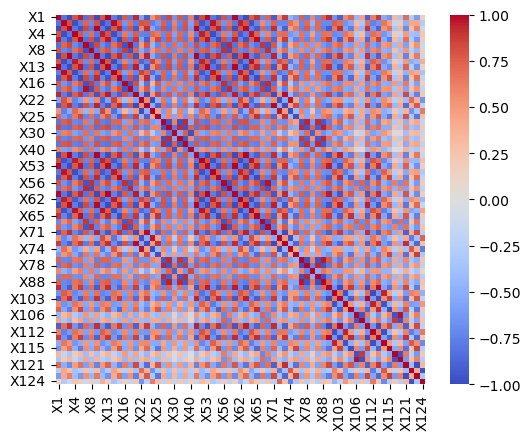

In [7]:
columns_drop = [col for col in data.columns if col not in both_significant]
sns.heatmap(data.drop(columns=columns_drop).corr(), square=True, vmax=1, vmin=-1, center=0, cmap='coolwarm')

In [8]:



x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(x_train.shape, x_test.shape)
pca =  PCA(n_components=0.95)
x_train_scaled = StandardScaler().fit_transform(x_train)
x_train_pca = pca.fit_transform(x_train_scaled)
print(f"Original number of features: {x_train.shape[1]}, Reduced number of features after PCA: {x_train_pca.shape[1]}")
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(random_state=42, class_weight='balanced'))
])

(126, 125) (32, 125)
Original number of features: 125, Reduced number of features after PCA: 10


In [14]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
param_grid_svm = {
    'svm__C': [0.01,0.1,0.5, 1, 10],
    'svm__kernel': ['linear', 'rbf','poly','sigmoid'],
    'svm__gamma': ['scale', 'auto'],
    'svm__degree': [2,3, 4, 5],  # Only relevant for 'poly' kernel, but GridSearchCV will handle it  # Added decision function shape to explore multi-class strategies
}

grid_svm = GridSearchCV(pipe, param_grid_svm, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

In [74]:
grid_svm.fit(x_train, y_train)
params = grid_svm.best_params_
score = grid_svm.best_score_
print(f"Best SVM parameters: {grid_svm.best_params_}")
print(f"Best SVM cross-validation F1 score: {grid_svm.best_score_}")

Fitting 10 folds for each of 160 candidates, totalling 1600 fits
Best SVM parameters: {'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM cross-validation F1 score: 0.6679561649221093


In [75]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
import numpy as np
param_grid_svm = {
    'svm__C': (0.1 * np.logspace(-1, 1, 100)).tolist(),  # More granular search over C values
    'svm__kernel': ['rbf','poly'],
    'svm__gamma': ['scale', 'auto'],
    'svm__degree': [1,2,3, 4, 5],  # Only relevant for 'poly' kernel, but GridSearchCV will handle it
}

grid_svm = GridSearchCV(pipe, param_grid_svm, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)

In [76]:
grid_svm.fit(x_train, y_train)
params = grid_svm.best_params_
score = grid_svm.best_score_
print(f"Best SVM parameters: {params}")
print(f"Best SVM cross-validation F1 score: {score}")

Fitting 10 folds for each of 2000 candidates, totalling 20000 fits
Best SVM parameters: {'svm__C': 0.07054802310718644, 'svm__degree': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best SVM cross-validation F1 score: 0.6785866627352697


### Now running testing procedure

In [69]:
# Remove 'svm__' prefix from param keys for SVC constructor
svm_params = {k.replace('svm__', ''): v for k, v in params.items()}
svm = SVC(class_weight='balanced', **svm_params)
svm.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.07054802310718644
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",1
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [70]:
y_preds = svm.predict(x_test)
print("\n=== SVM Classification Report ===")
print(classification_report(y_test, y_preds))



=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        26
           1       0.56      0.83      0.67         6

    accuracy                           0.84        32
   macro avg       0.76      0.84      0.78        32
weighted avg       0.88      0.84      0.85        32



### SVM Evaluation: ROC-AUC, Confusion Matrix

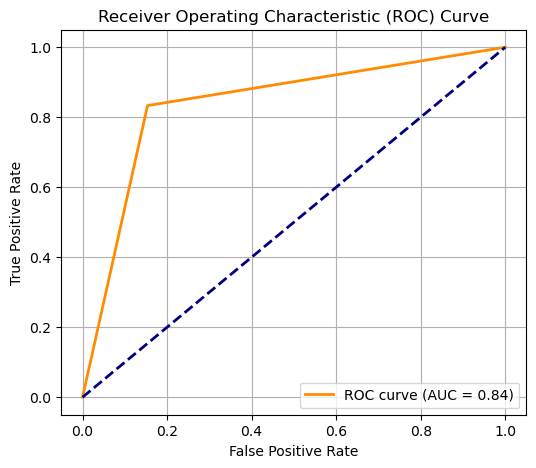

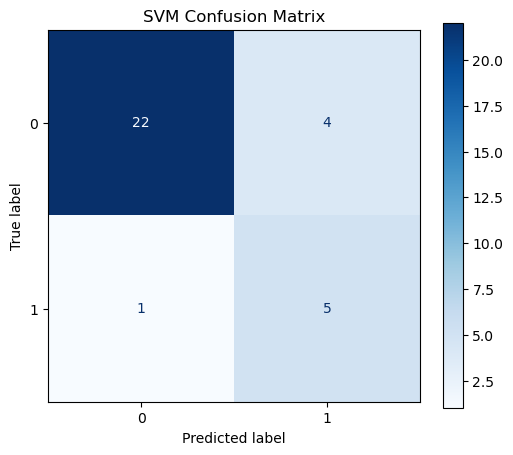

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.preprocessing import label_binarize
import itertools

fpr, tpr, _ = roc_curve(y_test, y_preds)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

### Final for Part 2

Training Time: 0.010757923126220703
SVM Training Performance:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85       126
           1       0.46      0.69      0.55        32

    accuracy                           0.77       158
   macro avg       0.68      0.74      0.70       158
weighted avg       0.82      0.77      0.79       158

Model saved to svm_part2_model.joblib


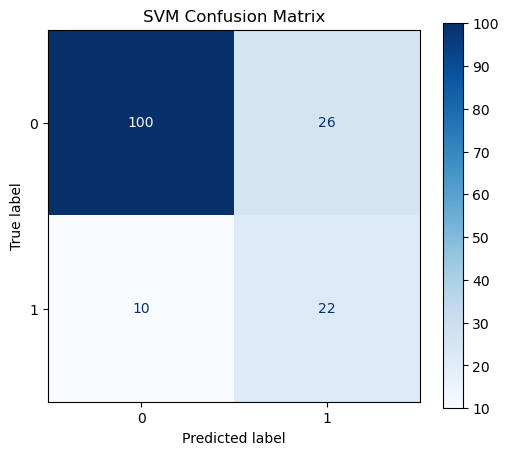

In [ ]:
import pandas as pd
import time
import numpy as np
import joblib
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Set to True for training, False for test/inference
TRAINING = True  # Change to False for test

dev_csv = 'PartII_dev.csv'  # Development set
test_csv = 'NEW_TEST_FILE.csv'  # Replace with actual test file when needed
model_path = 'svm_part2_model.joblib'
# Only use X1-X125 and Y
def load_data(csv_path):
    data = pd.read_csv(csv_path)
    X = data.drop(columns=['Y'])
    y = data['Y']
    return X, y

# Define pipeline and parameters
svm_params = {
    'C': 0.07054802310718644,
    'kernel': 'rbf',
    'gamma': 'scale',
    'degree': 1,
    'decision_function_shape': 'ovr'
}
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', SVC(random_state=42, class_weight='balanced', **svm_params))
])

if TRAINING:
    X_dev, y_dev = load_data(dev_csv)
    time_start = time.time()
    model = pipe.fit(X_dev, y_dev)
    print("Training Time:", time.time() - time_start)
    y_pred = model.predict(X_dev)
    print('SVM Training Performance:')
    #print(classification_report(y_dev, y_pred))
    joblib.dump({'model': model, 'params': svm_params}, model_path)
    print(f'Model saved to {model_path}')
    #cm = confusion_matrix(y_dev, y_pred)
    #disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    #fig, ax = plt.subplots(figsize=(6, 5))
    #disp.plot(ax=ax, cmap='Blues')
    #plt.title('SVM Confusion Matrix')
    #plt.show()
else:
    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model file {model_path} not found! Train first.')
    saved = joblib.load(model_path)
    model = saved['model']
    # Use dev set for demonstration; replace with test_csv for real test
    X_test, y_test = load_data(test_csv)
    time_start = time.time()
    y_pred = model.predict(X_test)
    print("Prediction Time:", time.time() - time_start)
    print('SVM Test Performance:')
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    plt.title('SVM Confusion Matrix')
    plt.show()
